<a href="https://colab.research.google.com/github/Fethulmubin/PCA_visualization/blob/main/PCA_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports and Dependencies

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression

from sklearn.neighbors import KNeighborsClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Loading the Dataset

In [2]:
data = load_breast_cancer()

X = data.data
y = data.target

print(X.shape)

(569, 30)


# Data Standardization

In [3]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# PCA from Scratch Implementation

In [4]:
class PCAFromScratch:

    def __init__(self, n_components):
        self.n_components = n_components

    def fit(self, X):
        # Center the data before calculating covariance.
        self.mean = np.mean(X, axis=0)
        X_centered = X - self.mean

        self.cov = np.cov(X_centered, rowvar=False)

        # The covariance matrix is symmetric, so eigh is stable and returns real values.
        eigenvalues, eigenvectors = np.linalg.eigh(self.cov)

        sorted_idx = np.argsort(eigenvalues)[::-1]
        self.eigenvalues = eigenvalues[sorted_idx]
        self.eigenvectors = eigenvectors[:, sorted_idx]

        self.components = self.eigenvectors[:, :self.n_components]
        self.components_ = self.components.T
        self.explained_variance = self.eigenvalues[:self.n_components]
        self.explained_variance_ratio = self.eigenvalues / np.sum(self.eigenvalues)
        self.explained_variance_ratio_ = self.explained_variance_ratio[:self.n_components]

        return self

    def transform(self, X):
        X_centered = X - self.mean
        return np.dot(X_centered, self.components)

    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

    def inverse_transform(self, X_pca):
        return np.dot(X_pca, self.components.T) + self.mean

# Data Projection into Principal Component Space

In [5]:
pca_scratch=PCAFromScratch(2)

X_pca_scratch=pca_scratch.fit_transform(X_scaled)

print(X_pca_scratch.shape)

(569, 2)


# PCA Using Scikit-Learn

In [6]:
pca=PCA(n_components=2)

X_pca=pca.fit_transform(X_scaled)

print(X_pca.shape)

(569, 2)


# PCA Visualization

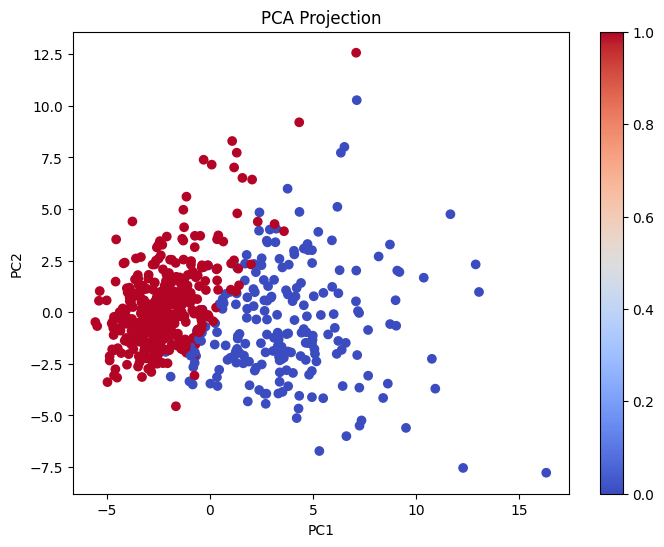

In [7]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y,
    cmap="coolwarm"
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("PCA Projection")

plt.colorbar()

plt.show()

# Cumulative Explained Variance

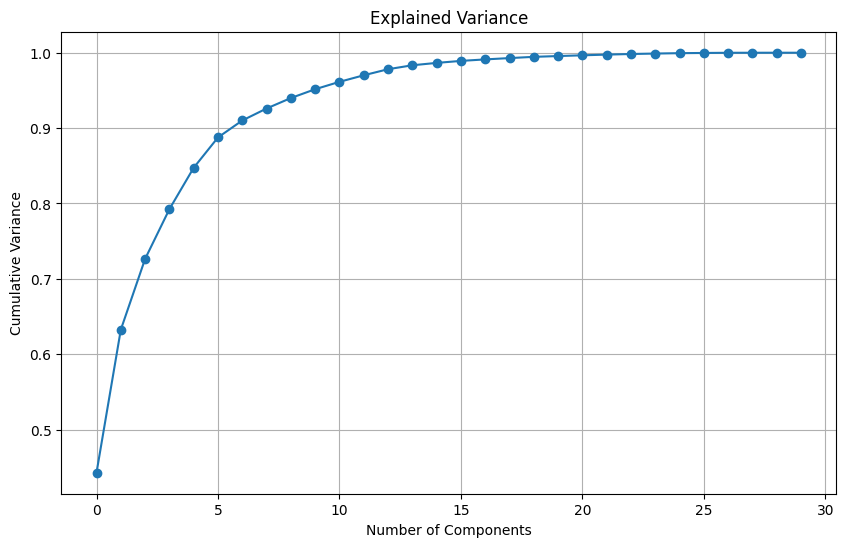

In [8]:
pca_full=PCA()

pca_full.fit(X_scaled)

plt.figure(figsize=(10,6))

plt.plot(
    np.cumsum(
        pca_full.explained_variance_ratio_
    ),
    marker='o'
)

plt.xlabel("Number of Components")

plt.ylabel("Cumulative Variance")

plt.title("Explained Variance")

plt.grid()

plt.show()

# Scree Plot

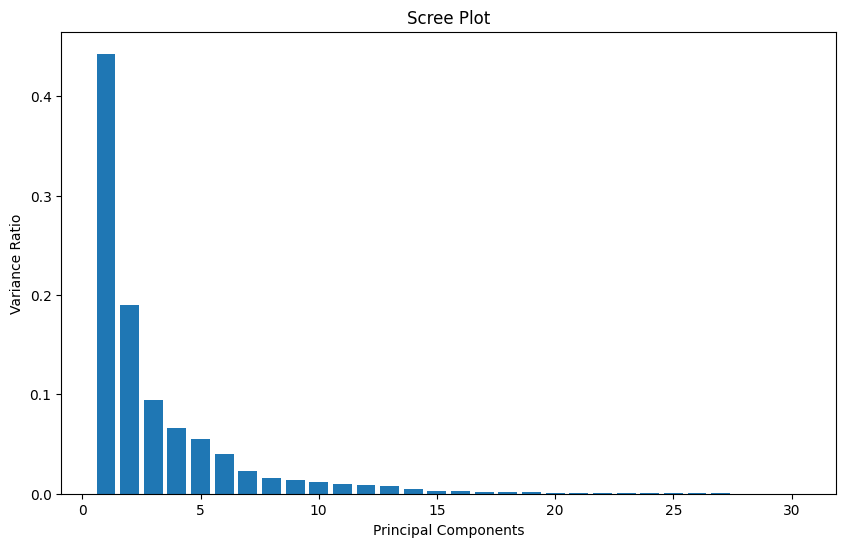

In [9]:
plt.figure(figsize=(10,6))

plt.bar(
    range(1,len(pca_full.explained_variance_ratio_)+1),
    pca_full.explained_variance_ratio_
)

plt.xlabel("Principal Components")

plt.ylabel("Variance Ratio")

plt.title("Scree Plot")

plt.show()

# Exploratory Data Analysis

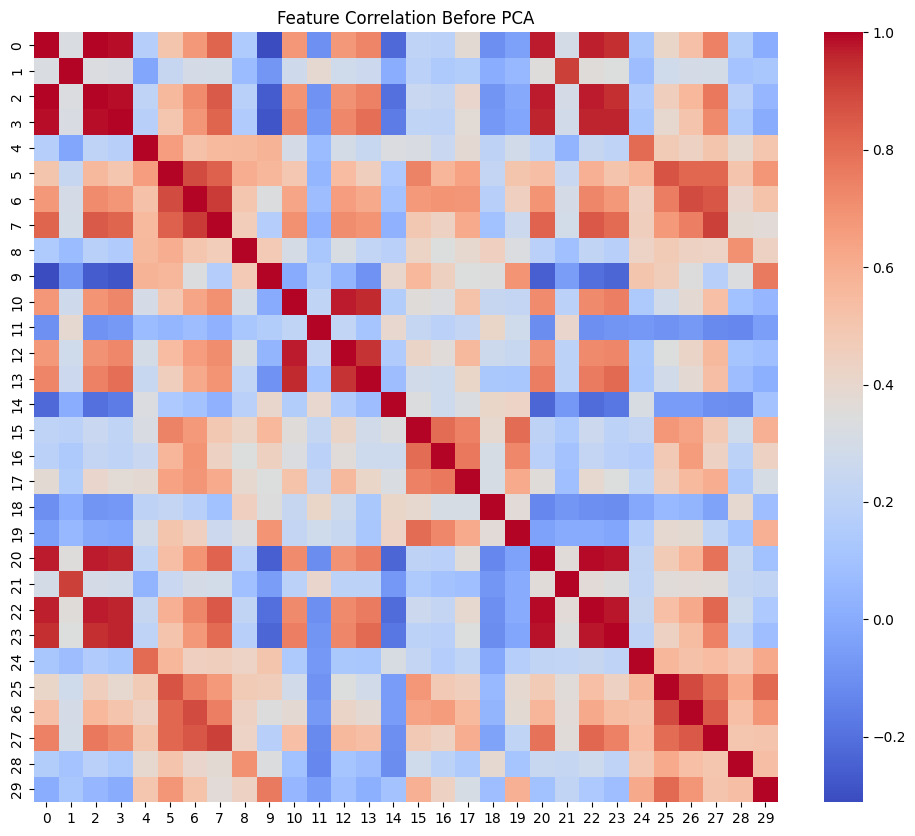

In [10]:
plt.figure(figsize=(12,10))

sns.heatmap(
    pd.DataFrame(X_scaled).corr(),
    cmap='coolwarm'
)

plt.title("Feature Correlation Before PCA")

plt.show()



# Covariance Matrix Computation

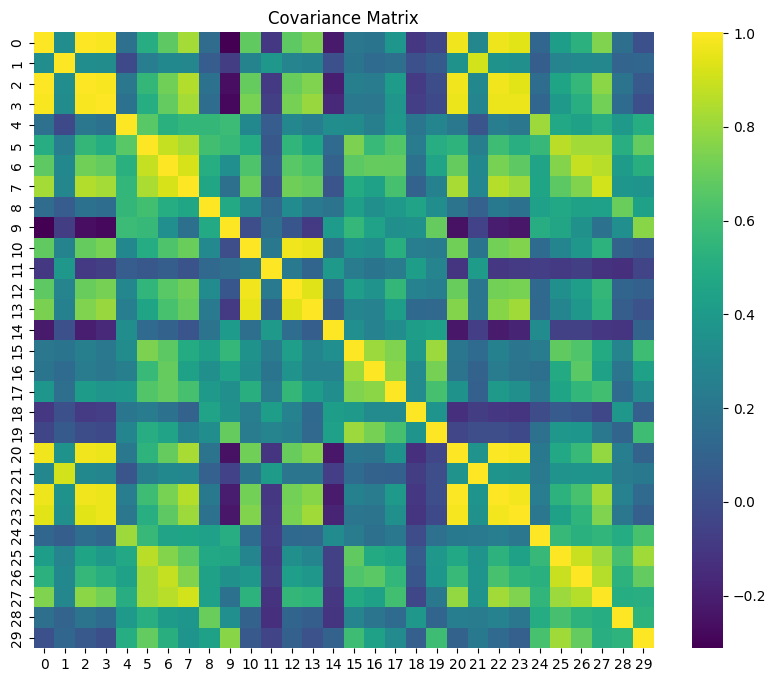

In [11]:
plt.figure(figsize=(10,8))

sns.heatmap(
    pca_scratch.cov,
    cmap="viridis"
)

plt.title("Covariance Matrix")

plt.show()

# Train-Test Split

In [12]:
X_train,X_test,y_train,y_test=train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

# Logistic Regression Model

In [13]:
# Logistic regression model

lr=LogisticRegression(max_iter=10000)

lr.fit(X_train,y_train)

pred=lr.predict(X_test)

print("Accuracy:",accuracy_score(y_test,pred))
print("Precision:",precision_score(y_test,pred))
print("Recall:",recall_score(y_test,pred))
print("F1:",f1_score(y_test,pred))

Accuracy: 0.9736842105263158
Precision: 0.9722222222222222
Recall: 0.9859154929577465
F1: 0.9790209790209791


# KNN Model

In [14]:
knn=KNeighborsClassifier()

knn.fit(X_train,y_train)

pred=knn.predict(X_test)

print("Accuracy:",accuracy_score(y_test,pred))

Accuracy: 0.9473684210526315


# Random Forest Model

In [15]:
rf=RandomForestClassifier()

rf.fit(X_train,y_train)

pred=rf.predict(X_test)

print("Accuracy:",accuracy_score(y_test,pred))

Accuracy: 0.956140350877193


# Best PCA Dimension Selection

In [16]:
pca=PCA(0.95)

X_pca=pca.fit_transform(X_scaled)

print(X_scaled.shape)

print(X_pca.shape)

(569, 30)
(569, 10)


# Train-Test Split with PCA

In [17]:
X_train_pca,X_test_pca,y_train,y_test=train_test_split(
    X_pca,
    y,
    test_size=0.2,
    random_state=42
)

# Logistic Regression with PCA

In [18]:
lr=LogisticRegression(max_iter=10000)

lr.fit(X_train_pca,y_train)

pred=lr.predict(X_test_pca)

print("Accuracy:",accuracy_score(y_test,pred))

Accuracy: 0.9824561403508771


# KNN with PCA

In [19]:
knn=KNeighborsClassifier()

knn.fit(X_train_pca,y_train)

pred=knn.predict(X_test_pca)

print("Accuracy:",accuracy_score(y_test,pred))

Accuracy: 0.956140350877193


# Random Forest with PCA

In [20]:
rf=RandomForestClassifier()

rf.fit(X_train_pca,y_train)

pred=rf.predict(X_test_pca)

print("Accuracy:",accuracy_score(y_test,pred))

Accuracy: 0.9473684210526315


# PCA Method Comparison

Compare the NumPy PCA implementation with Scikit-learn PCA on the same standardized dataset.

In [21]:
pca_scratch_compare = PCAFromScratch(n_components=2)
X_pca_scratch_compare = pca_scratch_compare.fit_transform(X_scaled)

pca_sklearn_compare = PCA(n_components=2)
X_pca_sklearn_compare = pca_sklearn_compare.fit_transform(X_scaled)

# PCA signs can flip while still representing the same components.
component_alignment = np.abs(
    np.diag(
        np.corrcoef(
            X_pca_scratch_compare.T,
            X_pca_sklearn_compare.T
        )[:2, 2:]
    )
)

pca_method_comparison = pd.DataFrame(
    {
        "Scratch Explained Variance Ratio": pca_scratch_compare.explained_variance_ratio_,
        "Sklearn Explained Variance Ratio": pca_sklearn_compare.explained_variance_ratio_,
        "Absolute Component Correlation": component_alignment,
    },
    index=["PC1", "PC2"]
)

pca_method_comparison

,Scratch Explained Variance Ratio,Sklearn Explained Variance Ratio,Absolute Component Correlation
PC1,0.442720,0.442720,1.0
PC2,0.189712,0.189712,1.0


# Model Comparison Before and After PCA

Train three classifiers on the original standardized features and on PCA-transformed features using the same train-test split.

In [22]:
pca_95 = PCA(n_components=0.95)
X_pca_95 = pca_95.fit_transform(X_scaled)

indices = np.arange(len(y))
train_idx, test_idx, y_train_compare, y_test_compare = train_test_split(
    indices,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train_without_pca = X_scaled[train_idx]
X_test_without_pca = X_scaled[test_idx]
X_train_with_pca = X_pca_95[train_idx]
X_test_with_pca = X_pca_95[test_idx]

models = {
    "Logistic Regression": LogisticRegression(max_iter=10000),
    "KNN": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(random_state=42),
}

results = []

for model_name, model in models.items():
    model.fit(X_train_without_pca, y_train_compare)
    pred_without_pca = model.predict(X_test_without_pca)

    model_with_pca = type(model)(**model.get_params())
    model_with_pca.fit(X_train_with_pca, y_train_compare)
    pred_with_pca = model_with_pca.predict(X_test_with_pca)

    for feature_set, predictions, feature_count in [
        ("Without PCA", pred_without_pca, X_train_without_pca.shape[1]),
        ("With PCA", pred_with_pca, X_train_with_pca.shape[1]),
    ]:
        results.append(
            {
                "Model": model_name,
                "Feature Set": feature_set,
                "Number of Features": feature_count,
                "Accuracy": accuracy_score(y_test_compare, predictions),
                "Precision": precision_score(y_test_compare, predictions),
                "Recall": recall_score(y_test_compare, predictions),
                "F1 Score": f1_score(y_test_compare, predictions),
            }
        )

comparison_df = pd.DataFrame(results)
comparison_df

,Model,Feature Set,Number of Features,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,Without PCA,30,0.982456,0.986111,0.986111,0.986111
1,Logistic Regression,With PCA,10,0.964912,0.985714,0.958333,0.971831
2,KNN,Without PCA,30,0.964912,0.959459,0.986111,0.972603
3,KNN,With PCA,10,0.956140,0.958904,0.972222,0.965517
4,Random Forest,Without PCA,30,0.956140,0.958904,0.972222,0.965517
5,Random Forest,With PCA,10,0.938596,0.971014,0.930556,0.950355


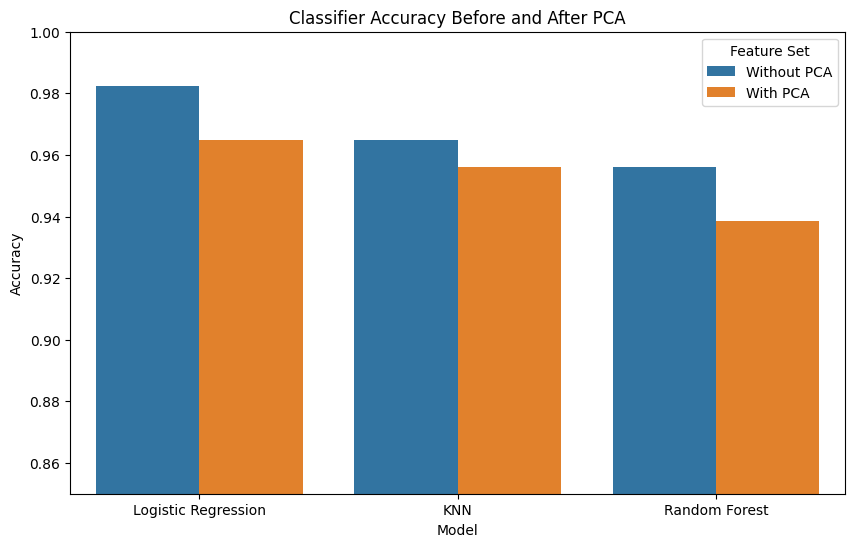

In [23]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=comparison_df,
    x="Model",
    y="Accuracy",
    hue="Feature Set"
)

plt.ylim(0.85, 1.0)
plt.title("Classifier Accuracy Before and After PCA")
plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.legend(title="Feature Set")
plt.show()